In [8]:
!pip install datasets

In [9]:
import pandas as pd
import numpy as np
from datetime import date
from dateutil.relativedelta import relativedelta
import os
from tqdm import tqdm
from collections import Counter
from transformers import (
  AutoTokenizer,
  AutoModel,
)
from datasets import Dataset
import torch

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
data_dir = "/content/drive/MyDrive/bda2024_mid_dataset"

files = os.listdir(data_dir)
print("View all datasets:")
for f in files:
    print(f)

View all datasets:
bda2024_微股力_財報數據-2年.csv
bda2024_微股力_籌碼數據-2年.csv
bda2024_微股力_個股交易數據-2年.csv
bda2024_微股力_社群PKTD-2年.csv
bda2024_202203-202402_討論數據_ptt.csv
bda2024_202203-202402_討論數據_dcard.csv
bda2024_202203-202402_內容數據_新聞1.csv
bda2024_202203-202402_內容數據_新聞2.csv
bda2024_202203-202402_內容數據_新聞3.csv
bda2024_202203-202402_討論數據_mobile01-1.csv
bda2024_202203-202402_討論數據_mobile01-2.csv
uncategorize.csv
news_df.csv
filtered_stock_data.csv
all_text_data_tsmc.csv


In [12]:
def load_df(filepath, preview=True):
    print(f"\n----- Loading {filepath}... -----")
    df = pd.read_csv(filepath)
    print(f"Size of dataframe: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    if preview:
        print(df.head())
    return df

In [13]:
folder_path = '/content/drive/MyDrive/bda2024_mid_dataset/'

news1_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞1.csv", preview=False)
news2_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞2.csv", preview=False)
news3_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞3.csv", preview=False)
disc_ptt_df = load_df(folder_path+"bda2024_202203-202402_討論數據_ptt.csv", preview=False)

noreply_df = pd.concat([news1_df, news2_df, news3_df, disc_ptt_df], ignore_index=True)

disc_dcard_df = load_df(folder_path+"bda2024_202203-202402_討論數據_dcard.csv", preview=False)
disc_dcard_df.rename(columns={'forum': 'p_type'}, inplace=True)    # Repair column name typo in data
disc_m1_df = load_df(folder_path+"bda2024_202203-202402_討論數據_mobile01-1.csv", preview=False)
disc_m2_df = load_df(folder_path+"bda2024_202203-202402_討論數據_mobile01-2.csv", preview=False)

url_pattern_m = r't=(\d+)'
url_pattern_d = r'p/(\d+)'
disc_m1_df['thread_id'] = disc_m1_df['page_url'].str.extract(url_pattern_m)
disc_m2_df['thread_id'] = disc_m2_df['page_url'].str.extract(url_pattern_m)
disc_dcard_df['thread_id'] = disc_dcard_df['page_url'].str.extract(url_pattern_d)

reply_df = pd.concat([disc_dcard_df, disc_m1_df, disc_m2_df], ignore_index=True)

transaction_df = load_df(folder_path+"bda2024_微股力_個股交易數據-2年.csv", preview=False)
report_df = load_df(folder_path+"bda2024_微股力_財報數據-2年.csv", preview=False)
chip_df = load_df(folder_path+"bda2024_微股力_籌碼數據-2年.csv", preview=False)
transaction_df['stock_symbol'] = transaction_df['stock_symbol'].astype(str)
chip_df['stock_symbol'] = chip_df['stock_symbol'].astype(str)    # Repair mixed data types



----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞1.csv... -----
Size of dataframe: (179449, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞2.csv... -----
Size of dataframe: (15114, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞3.csv... -----
Size of dataframe: (290929, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_討論數據_ptt.csv... -----
Size of dataframe: (50805, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_

<ipython-input-12-3ba66dfef298>:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Size of dataframe: (1154225, 8)
Columns: ['stock_name', 'stock_symbol', 'open', 'high', 'low', 'close', 'volume', 'date']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_微股力_財報數據-2年.csv... -----
Size of dataframe: (16482, 16)
Columns: ['stock_name', 'stock_symbol', 'period', 'gross_profit_margin', 'operating_profit_margin', 'net_profit_margin', 'return_on_equity', 'debt_ratio', 'interest_coverage', 'current_ratio', 'quick_ratio', 'accounts_turnover', 'inventory_turnover', 'eps', 'book_value_per_share', 'date']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_微股力_籌碼數據-2年.csv... -----


<ipython-input-12-3ba66dfef298>:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Size of dataframe: (998031, 9)
Columns: ['stock_name', 'stock_symbol', 'foreign_investor_bought', 'foreign_investor_sold', 'investment_trust_bought', 'investment_trust_sold', 'dealer_bought', 'dealer_sold', 'date']


## numerical data

In [14]:
#Only use the stocks appear in both df
left = np.setdiff1d(report_df['stock_name'].unique(), chip_df['stock_name'].unique())
right = np.setdiff1d(chip_df['stock_name'].unique(), report_df['stock_name'].unique())
inner = np.intersect1d(chip_df['stock_name'].unique(), report_df['stock_name'].unique())

all = sum([len(left), len(right), len(inner)])
discard = sum([len(left), len(right)])

print(f'Discarded stocks number: {discard}')
print(f'Retained stocks number: {len(inner)}')
print(f'percent of discarded stocks: {discard/all}')

Discarded stocks number: 635
Retained stocks number: 1834
percent of discarded stocks: 0.25718914540299714


In [15]:
# join on stock_ symbol where df_chip.date in (df_fin.date - 3 months)
report_df['date'] = pd.to_datetime(report_df['date']).dt.date
chip_df['date'] = pd.to_datetime(chip_df['date']).dt.date
noreply_df['post_time'] = pd.to_datetime(noreply_df['post_time']).dt.date
reply_df['post_time'] = pd.to_datetime(reply_df['post_time']).dt.date

df_fin = report_df.loc[report_df['period']=='Q']

tmp = pd.merge(chip_df, df_fin, on='stock_name', suffixes=['_chip', '_fin'], how='inner')

#26 stocks dropped in after this line due to the mismatch of date
df_finchip = tmp.loc[(tmp['date_fin'] - relativedelta(months=3) <= tmp['date_chip']) & (tmp['date_chip'] < tmp['date_fin'])]

## text data

### datas with replies

In [16]:
'''
Remove deleted replies(Dcard)
Remove urls
*Whether to remove replies that are not at the date of main?

*Some replies don't have its main, outer join and fillna?
*Replies and main can have different urls -- fixed, unique id is in url
*Same title problem -- fixed by merging on unique id in url.
*About 40% of the rows don't have any stock name mentioned
*Make stock_name_tagger check stock symbols too
'''

# Separate main content and replies
main = reply_df[reply_df['content_type'] == 'main'][['thread_id', 'post_time', 'title', 'content', 'page_url']].copy()
replies = reply_df[reply_df['content_type'] == 'reply'][['thread_id', 'title', 'content', 'page_url']].copy()

# Remove #公告
main = main[~main['title'].str.contains('#公告', regex=False)]

# Define content to be removed
remove_content = ['已經刪除的內容就像 Dcard 一樣，錯過是無法再相見的！', '此篇文章為轉貼文章，請更新至最新版本觀看完整內容。',
                  '這則留言的文字、圖片或影片，因 交換個人資料（電話、電子郵件、通訊軟體 ID、交友軟體 ID 等），目前已進行移除處理。']

# Filter out the removed content
replies = replies[~replies['content'].isin(remove_content)]

# Regex to remove URLs/ new line symbols
regex = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+|<BR>|\n'

# Remove URLs from 'content' column in replies
main['content'] = main['content'].str.replace(regex, '', regex=True)
replies['content'] = replies['content'].str.replace(regex, '', regex=True)

# Merge main and replies
df_mapped = pd.merge(main, replies, on='thread_id', suffixes=['_main', '_re'], how='outer')

# Group by 'thread_id' and concatenate replies
replies_grouped = df_mapped.groupby('thread_id')['content_re'].agg(lambda x: ' '.join(x.dropna()))

# Join the grouped replies back to the main DataFrame
main = main.join(replies_grouped, on='thread_id').fillna('')
main.rename(columns={'content_re': 'merged_replies'}, inplace=True)
main['all_content'] = main[['title', 'content', 'merged_replies']].agg(' '.join, axis=1)

In [17]:
def process_duplicated(df):
    # Group by 'title' and 'post_time' and find duplicates by these fields
    duplicates = df.duplicated(subset=['title', 'post_time'], keep=False)
    # Work only with duplicated entries
    df_duplicates = df[duplicates]
    # Find the longest 'all_content' within each group of 'title' and 'post_time'
    idx_to_keep = df_duplicates.groupby(['title', 'post_time'])['all_content'].apply(lambda x: x.str.len().idxmax())
    #print(df_duplicates.groupby(['title', 'post_time'])['all_content'].head(5))
    #print(idx_to_keep)
    # Filter out duplicates except for the longest 'all_content' entries
    df_clean = df.drop(df_duplicates.index)  # Drop all duplicates
    df_clean = pd.concat([df_clean, df.loc[idx_to_keep]])  # Concatenate entries to keep with non-duplicate data

    return df_clean

In [18]:
df_reply_merged = process_duplicated(main).drop(columns = "page_url")
df_reply_merged.iloc[0]

thread_id                                                 238238119
post_time                                                2022-03-01
title                                                   #標的 3/1盤前功課
content           週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股市利空，只會是人倫悲劇目...
merged_replies           專業給推 感謝分享 存股台積電建議跌到多少可買進呢 謝謝 不知道今天是否將華欣賣掉🥲
all_content       #標的 3/1盤前功課 週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股...
Name: 21, dtype: object

In [19]:
# Basic tagger
stock_list = df_finchip['stock_name'].unique()
def stock_name_tagger_1to1(row, stock_list=stock_list):
    title = row['title']
    all_content = row['all_content']

    title_stock = [stock for stock in stock_list if stock in title]
    if len(title_stock) == 1:
        return title_stock[0]

    stock_counts = {}
    for stock in stock_list:
        count = all_content.count(stock)
        if count > 0:
            stock_counts[stock] = count
    if stock_counts:
        return max(stock_counts, key=stock_counts.get)
    return np.nan

In [20]:
!pip install pyahocorasick

In [21]:
# Tagger with Aho–Corasick algorithm(faster)
import ahocorasick

def build_automaton(stock_list):
    # Initialize the automaton
    A = ahocorasick.Automaton()
    for idx, stock in enumerate(stock_list):
        A.add_word(stock, (idx, stock))
    A.make_automaton()
    return A

# Pre-build the automaton with the unique stock names
stock_list = df_finchip['stock_name'].unique()
automaton = build_automaton(stock_list)

def stock_name_tagger_1to1_ac(row, automaton):
    title = row['title']
    all_content = row['all_content']

    # Search for stock names in the title
    title_stocks = set()
    for end_index, (_, stock) in automaton.iter(title):
        title_stocks.add(stock)
    if len(title_stocks) == 1:
        return next(iter(title_stocks))

    # Count occurrences in all_content using the automaton
    content_stock_count = {}
    for end_index, (_, stock) in automaton.iter(all_content):
        if stock in content_stock_count:
            content_stock_count[stock] += 1
        else:
            content_stock_count[stock] = 1

    # Determine the stock name with the maximum count
    if content_stock_count:
        return max(content_stock_count, key=content_stock_count.get)

    return np.nan

In [22]:
tqdm.pandas()
df_reply_1to1 = df_reply_merged.copy()
df_reply_1to1['stock_name'] = df_reply_1to1.progress_apply(stock_name_tagger_1to1, axis=1)
df_reply_1to1['stock_name_ac'] = df_reply_1to1.progress_apply(lambda row: stock_name_tagger_1to1_ac(row, automaton), axis=1)

100%|██████████| 32234/32234 [00:12<00:00, 2541.60it/s]


In [23]:
mentioned_num = df_reply_1to1[~df_reply_1to1['stock_name'].isnull()].shape[0]
unmentioned_num = df_reply_1to1[df_reply_1to1['stock_name'].isnull()].shape[0]
print(f'Rows with stock name: {mentioned_num}\nRows without stock name: {unmentioned_num}\n{mentioned_num/(unmentioned_num+mentioned_num)}% retained')

used_stocks = len(df_reply_1to1['stock_name'].dropna().unique())
used_stocks_2 = len(df_reply_1to1['stock_name_ac'].dropna().unique())
print(f'{used_stocks/len(stock_list)}% of stock names tagged')
print(f'{used_stocks_2/len(stock_list)}% of stock names tagged')

Rows with stock name: 19859
Rows without stock name: 12375
0.6160886020971645% retained
0.6178097345132744% of stock names tagged
0.6338495575221239% of stock names tagged


### datas without replies

In [24]:
#Remove [公告]
df = noreply_df[~noreply_df['title'].str.contains('[公告]', regex=False)][['id', 'post_time', 'title', 'content']].copy()
df['content'] = df['content'].str.replace(regex, '', regex=True).fillna('')
df['all_content'] = df[['title', 'content']].agg(''.join, axis=1)

df_noreply = process_duplicated(df)
df_noreply['stock_name_ac'] = df_noreply.progress_apply(lambda row: stock_name_tagger_1to1_ac(row, automaton), axis=1)
df_noreply['stock_name'] = df_noreply.progress_apply(stock_name_tagger_1to1, axis=1)

100%|██████████| 530699/530699 [07:23<00:00, 1197.39it/s]


In [25]:
all_text_data = pd.concat([df_reply_1to1.dropna()[['post_time', 'all_content', 'stock_name']], df_noreply.dropna()[['post_time', 'all_content', 'stock_name']]])

In [26]:
all_text_data.to_csv('all_text_data.csv', index=False)

In [27]:
all_text_data


,post_time,all_content,stock_name
21,2022-03-01,#標的 3/1盤前功課 週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股...,台積電
47,2022-03-01,#請益 台積電跌了要買嗎 股市新手想請問現在為什麼會跌成這樣跟烏俄衝突有關嗎那感覺上進場的時...,台積電
57,2022-03-01,請問圖中買盤是發生什麼事 股市小白來了，直接上圖幾分鐘後想請問這個1000張的大量是從何而來...,大量
62,2022-03-01,#請益 想詢問交割款問題 各位先進好，因為小弟之前都在用美股美商證券，最近把一些些資金移回台...,承業醫
70,2022-03-01,#分享 勸世文 千萬不要碰當沖 今天早上起床看到比特幣大漲想說來當沖板卡股，結果還是玩不贏大...,智原
...,...,...,...
190456,2023-10-14,鴻海科技日、台積電法說會和能源週 台股下週重頭戲（中央社記者張建中台北14日電）台股週線連3...,台積電
233598,2023-02-09,麥可貝瑞張貼2000年比較圖 暗示降息美股也不妙MoneyDJ新聞 2023-02-09 1...,金利
190098,2023-09-27,黃天牧：疫後國際情勢撲朔迷離 看好台股前景（中央社記者謝方娪台北27日電）美國升息近尾聲，但...,精確
194062,2024-02-14,龍年第一盤再現34年高點！謝金河5點看日股破繭而出夢幻劇本：讓全球投資專家跌破很多眼鏡2月1...,台積電


## 股價資料、設定漲跌幅


In [40]:
ase = transaction_df
#ase = stock[stock['stock_symbol'].str.contains('2303')]
#ase['年月日'] = pd.to_datetime(ase['年月日']).dt.date #將日期的時間部分去除
ase['date'] = pd.to_datetime(transaction_df ['date']).dt.date #將日期的時間部分去除
ase = ase.sort_values(by = 'date').reset_index(drop = True)

# 計算各股票的單日漲跌幅度
ase['單日漲跌幅(%)'] = ase.groupby('stock_name')['close'].pct_change()
ase = ase[ase['stock_name'] == '台積電']

# 將單日漲跌幅度分類為漲、跌或持平
def categorize_label(x):
    if x > 0.02:
        return '1'
    elif x < -0.02:
        return '-1'
    else:
        return '0'

# 創建 label 欄位並套用 categorize_label 函數
ase['label'] = ase['單日漲跌幅(%)'].apply(categorize_label)
# type(ase['date'])

ase

<ipython-input-40-a9d66406d337>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ase['label'] = ase['單日漲跌幅(%)'].apply(categorize_label)


,stock_name,stock_symbol,open,high,low,close,volume,date,單日漲跌幅(%),label
1502,台積電,2330,599.0,610.0,599.0,604.0,70304,2022-03-01,NaN,0
3552,台積電,2330,601.0,605.0,600.0,601.0,42428,2022-03-02,-0.004967,0
6115,台積電,2330,603.0,607.0,601.0,602.0,37104,2022-03-03,0.001664,0
7566,台積電,2330,595.0,597.0,592.0,595.0,65235,2022-03-04,-0.011628,-1
9112,台積電,2330,580.0,581.0,575.0,576.0,97168,2022-03-07,-0.031933,-1
...,...,...,...,...,...,...,...,...,...,...
1141873,台積電,2330,675.0,688.0,675.0,687.0,31404,2024-02-20,0.013274,1
1146325,台積電,2330,678.0,683.0,678.0,681.0,31981,2024-02-21,-0.008734,0
1147469,台積電,2330,695.0,695.0,685.0,692.0,34269,2024-02-22,0.016153,1
1151618,台積電,2330,701.0,703.0,696.0,697.0,48404,2024-02-23,0.007225,0


In [41]:
ase['label'].value_counts()

label
0     252
-1    118
1     115
Name: count, dtype: int64

## 篩選出 all_text_data 中台積電新聞/討論、股價

In [42]:
all_text_data_tsmc = all_text_data[all_text_data['stock_name'] == '台積電']
all_text_data_tsmc.to_csv('all_text_data_tsmc.csv', index=False)

all_text_data_tsmc = all_text_data_tsmc.dropna(subset=['post_time'])
all_text_data_tsmc.to_csv('all_text_data_tsmc.csv', index=False)

all_text_data_tsmc

,post_time,all_content,stock_name
21,2022-03-01,#標的 3/1盤前功課 週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股...,台積電
47,2022-03-01,#請益 台積電跌了要買嗎 股市新手想請問現在為什麼會跌成這樣跟烏俄衝突有關嗎那感覺上進場的時...,台積電
139,2022-03-01,#請益 0050，2330；美股ETF，台股ETF？ 小弟今年大四生，還是個小韭菜，萌生一些...,台積電
356,2022-03-01,#標的 3/2 盤前功課 1. 如預期的想壓台積電，沒想到開盤兩萬張的賣壓輕鬆化解，期貨空單...,台積電
605,2022-03-02,#請益 600以下台積電是不是上天賜予的禮物 大家都知道小妹我台積電狂粉啦從上次買完到現在心...,台積電
...,...,...,...
381629,2023-09-17,高階iPhone 15規格升級 台廠握關鍵技術搶商機（中央社記者鍾榮峰台北2023年9月17...,台積電
179496,2022-12-01,鮑爾放鴿 新台幣爆量狂漲2.69角收近3個月新高（中央社記者潘姿羽台北1日電）美國聯準會鮑爾...,台積電
190456,2023-10-14,鴻海科技日、台積電法說會和能源週 台股下週重頭戲（中央社記者張建中台北14日電）台股週線連3...,台積電
194062,2024-02-14,龍年第一盤再現34年高點！謝金河5點看日股破繭而出夢幻劇本：讓全球投資專家跌破很多眼鏡2月1...,台積電


In [43]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

# Convert dates to datetime objects
all_text_data_tsmc['post_time'] = pd.to_datetime(all_text_data_tsmc['post_time'])
ase['date'] = pd.to_datetime(ase['date'])

# Add a new column in all_text_data_tsmc for three days later
all_text_data_tsmc['three_days_later'] = all_text_data_tsmc['post_time'] + timedelta(days=3)

# Merge all_text_data_tsmc with ase using the three_days_later column in all_text_data_tsmc
merged_data = pd.merge(all_text_data_tsmc, ase, left_on='three_days_later', right_on='date', how='inner')




## 建立測試、訓練集


In [44]:
# Filter news content and labels based on the given dates
start_date_train, end_date_train = datetime(2022, 8, 1).date(), datetime(2022, 10, 30).date()
start_date_test, end_date_test = datetime(2022, 11, 1).date(), datetime(2022, 11, 30).date()

x_train = merged_data[(merged_data['post_time'].dt.date >= start_date_train) & (merged_data['post_time'].dt.date <= end_date_train)]['all_content']
y_train = merged_data[(merged_data['post_time'].dt.date >= start_date_train) & (merged_data['post_time'].dt.date <= end_date_train)]['label']

x_test = merged_data[(merged_data['post_time'].dt.date >= start_date_test) & (merged_data['post_time'].dt.date <= end_date_test)]['all_content']
y_test = merged_data[(merged_data['post_time'].dt.date >= start_date_test) & (merged_data['post_time'].dt.date <= end_date_test)]['label']

# Save the filtered data
filtered_data_train = pd.DataFrame({'all_content': x_train, 'label': y_train})
filtered_data_train.to_csv('filtered_data_train.csv', index=False)

filtered_data_test = pd.DataFrame({'all_content': x_test, 'label': y_test})
filtered_data_test.to_csv('filtered_data_test.csv', index=False)

In [45]:
merged_data.to_csv('merged_data.csv', index=False)

In [46]:
from google.colab import drive

# 授權訪問 Google Drive
drive.mount('/content/drive')

# 將 merged_data 匯出到 Google Drive 中
merged_data.to_csv('/content/drive/My Drive/merged_data.csv', index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
merged_data['label'].value_counts()

label
0     6866
-1    3266
1     3162
Name: count, dtype: int64

## Monpa

In [37]:
!pip install monpa

## 取特徵、關鍵字，生成 TF-IDF

1. 獲取不重複的關鍵字：
unique_positive 和 unique_negative 是通過比較看漲和看跌的特徵集來確定的，目的是找出那些僅在一個類別中顯著而在另一個類別中不顯著的詞彙。這有助於提高模型預測的精確度，因為這些詞彙能夠更好地區分不同的股票行情。
這一步確保每個類別都有其獨特的代表性詞彙，這些詞彙將用於構建模型的特徵。

2. 重新生成TF-IDF使用過濾後的關鍵字：
使用過濾後的詞彙重新創建一個TfidfVectorizer。這個新的向量化器將只考慮那些被識別為對預測目標有高度區分性的詞彙。
x_train_tfidf_revised 是對原始訓練集x_train使用這個新的詞彙表重新計算得到的TF-IDF矩陣。這樣可以保證模型訓練使用的特徵是最具區分性和預測價值的。

In [ ]:
import monpa
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
import numpy as np
import emoji
import re

# Tokenizer 使用 Monpa 斷詞
def monpa_tokenizer(text):
    text = emoji.replace_emoji(text, replace='')
    tokens = monpa.cut(text)
    # 移除停用詞、數字以及特殊字符
    tokens_filtered = [token for token in tokens if not re.match(r'^[^\u4e00-\u9fffA-Za-z]+$', token)]
    return tokens_filtered

# 整體 TF-IDF
tfidf_vectorizer = TfidfVectorizer(tokenizer=monpa_tokenizer, max_features=20000)
x_train_tfidf_matrix = tfidf_vectorizer.fit_transform(x_train)

In [59]:
pip install emoji


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.8/433.8 kB 7.2 MB/s eta 0:00:00


## Modeling

MLP Classifier Balanced accuracy: 0.3561


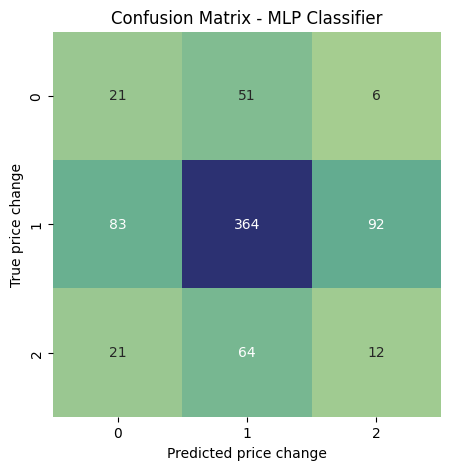

In [159]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

mlp_clf = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', random_state=42, max_iter=1000)

mlp_clf.fit(x_train_tfidf_matrix, y_train_mapped)

z_test_pred_mlp = mlp_clf.predict(x_test_tfidf_matrix)

accuracy_mlp = balanced_accuracy_score(y_test_mapped, z_test_pred_mlp)
print(f"MLP Classifier Balanced accuracy: {accuracy_mlp:.4f}")

cm = confusion_matrix(y_test_mapped, z_test_pred_mlp)
class_labels = ['0', '1', '2']
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted price change")
plt.ylabel("True price change")
plt.title("Confusion Matrix - MLP Classifier")
plt.show()


In [32]:
# SVM - Param
# 跑太久，SVM 找最佳參數

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(filtered_data_train['label'])
y_test_encoded = label_encoder.transform(filtered_data_test['label'])

# 定義VM模型
svm = SVC()

# 定義參數
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],  # 核函數
    'kernel': ['rbf', 'poly', 'linear']
}

# 創建GridSearchCV
grid_search = GridSearchCV(svm, param_grid, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(x_train_tfidf_matrix, y_train)

# 找最佳参數
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Best parameters found:  {'C': 1, 'gamma': 1, 'kernel': 'poly'}


In [ ]:
# Word2Vec

import gensim.downloader as api
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 下載並加載預訓練的 Word2Vec 模型
word2vec_model = api.load("word2vec-google-news-300")

# 將文本轉換為 word embeddings 向量
def text_to_embeddings(text):
    embeddings = []
    for word in text.split():
        if word in word2vec_model:
            embeddings.append(word2vec_model[word])
    return np.mean(embeddings, axis=0) if embeddings else np.zeros(word2vec_model.vector_size)

# 將 x_train 和 x_test 轉換為 word embeddings 向量
x_train_emb = np.array([text_to_embeddings(text) for text in x_train_processed])
x_test_emb = np.array([text_to_embeddings(text) for text in x_test_processed])

# 創建 SVM 分類器
svm_clf = SVC(kernel='poly')

# 訓練 SVM 分類器
svm_clf.fit(x_train_emb, y_train)

# 在測試集上進行預測
y_pred_emb = svm_clf.predict(x_test_emb)

# 顯示分類報告
print(classification_report(y_test, y_pred_emb))

# 計算準確率
accuracy_emb = accuracy_score(y_test, y_pred_emb)
print(f"SVM Classifier Accuracy: {accuracy_emb:.4f}")

# 看結果
cm = confusion_matrix(y_test, y_pred_emb)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

          -1       0.15      0.06      0.09        78
           0       0.76      0.94      0.84       539
           1       0.17      0.03      0.05        97

    accuracy                           0.72       714
   macro avg       0.36      0.34      0.33       714
weighted avg       0.61      0.72      0.65       714

Voting Classifier Accuracy: 0.7171


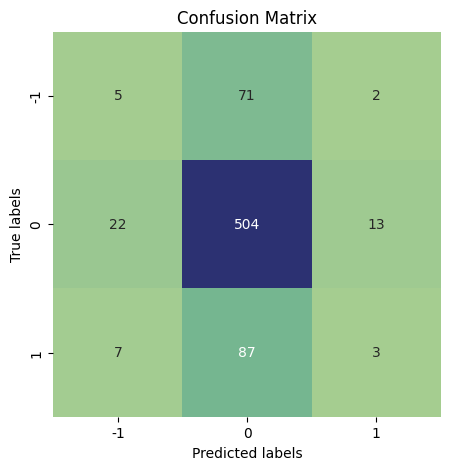

In [145]:
# SVM
import gensim.downloader as api
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 創建 SVM 分類器
# svm_clf = SVC(kernel='linear', probability=True)

# 將類別標籤轉換為整數
y_train_int = y_train.astype(int)

# 創建 SVM 分類器，並設置 class_weight 參數
svm_clf = SVC(kernel='rbf', C = 1, probability=True, class_weight={1: 5, -1: 5, 0: 1})

# 訓練 SVM 分類器
svm_clf.fit(x_train_tfidf_matrix, y_train_int)
# svm_clf.fit(x_train_tfidf_matrix, y_train)

y_test_pred = svm_clf.predict(x_test_tfidf_matrix)

y_test_int = y_test.astype(int)
print(classification_report(y_test_int, y_test_pred))

# # 計算準確率
accuracy_svm = accuracy_score(y_test_int, y_test_pred)
print(f"Voting Classifier Accuracy: {accuracy_svm:.4f}")

# 看結果
cm = confusion_matrix(y_test_int, y_test_pred)
class_labels = ['-1', '0','1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()



              precision    recall  f1-score   support

          -1       0.11      0.03      0.04        78
           0       0.75      0.93      0.83       539
           1       0.09      0.02      0.03        97

    accuracy                           0.71       714
   macro avg       0.31      0.33      0.30       714
weighted avg       0.59      0.71      0.64       714

Random Forest Classifier Accuracy: 0.7101


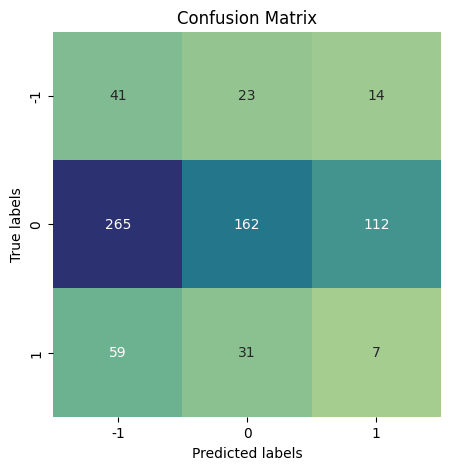

In [132]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 創建隨機森林分類器
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 訓練隨機森林分類器
rf_clf.fit(x_train_tfidf_matrix, y_train)

# 在測試集上進行預測
y_test_pred_rf = rf_clf.predict(x_test_tfidf_matrix)

# 顯示分類報告
print(classification_report(y_test, y_test_pred_rf))

# 計算準確率
accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

# 看結果
cm = confusion_matrix(y_test_int, y_test_pred)
class_labels = ['-1', '0','1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

KNN Classifier Accuracy: 0.5504
              precision    recall  f1-score   support

          -1       0.12      0.26      0.16        78
           0       0.76      0.68      0.72       539
           1       0.09      0.05      0.07        97

    accuracy                           0.55       714
   macro avg       0.32      0.33      0.31       714
weighted avg       0.60      0.55      0.57       714



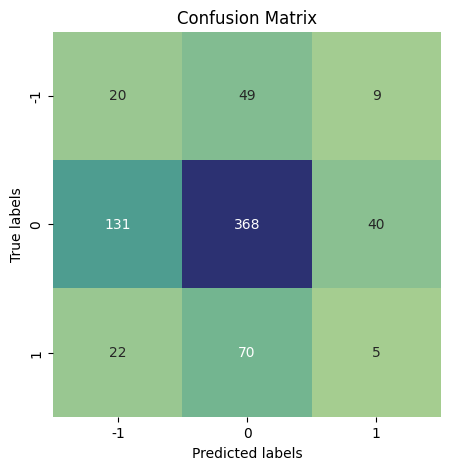

In [146]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 創建 KNN 分類器
knn_clf = KNeighborsClassifier(n_neighbors=5)

# 訓練 KNN 分類器
knn_clf.fit(x_train_tfidf_matrix, y_train_int)

# 使用訓練好的模型進行預測
y_test_pred = knn_clf.predict(x_test_tfidf_matrix)

# 計算準確率
accuracy_knn = accuracy_score(y_test_int, y_test_pred)
print(f"KNN Classifier Accuracy: {accuracy_knn:.4f}")

# 顯示分類報告
print(classification_report(y_test_int, y_test_pred))

# 看結果
cm = confusion_matrix(y_test_int, y_test_pred)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()



              precision    recall  f1-score   support

          -1       0.03      0.01      0.02        78
           0       0.75      0.87      0.81       539
           1       0.10      0.05      0.07        97

    accuracy                           0.67       714
   macro avg       0.29      0.31      0.30       714
weighted avg       0.58      0.67      0.62       714

Random Forest Classifier Accuracy: 0.6681


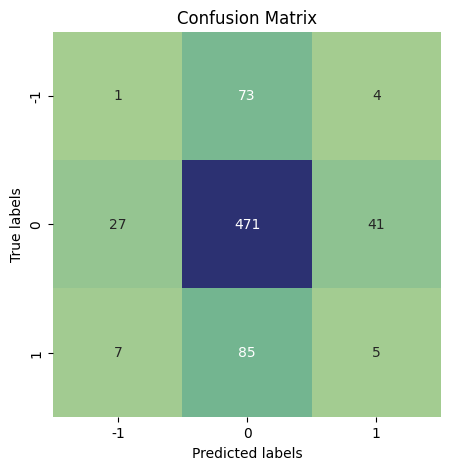

In [170]:
# Desicion Tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 創建隨機森林分類器
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 訓練隨機森林分類器
rf_clf.fit(x_train_emb, y_train)

# 在測試集上進行預測
y_pred_emb = rf_clf.predict(x_test_emb)

# 顯示分類報告
print(classification_report(y_test, y_pred_emb))

# 計算準確率
accuracy_emb = accuracy_score(y_test, y_pred_emb)
print(f"Random Forest Classifier Accuracy: {accuracy_emb:.4f}")

# 看結果
cm = confusion_matrix(y_test, y_pred_emb)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()


XGBoost Classifier Accuracy: 0.6499


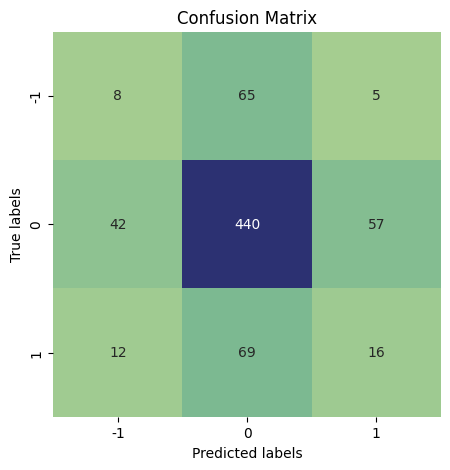

In [152]:
# XGBoost
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

label_mapping = {-1: 0, 0: 1, 1: 2}
y_train_mapped = y_train_int.map(label_mapping)
y_test_mapped = y_test_int.map(label_mapping)

xgb_clf = xgb.XGBClassifier()

xgb_clf.fit(x_train_tfidf_matrix, y_train_mapped)

y_test_pred = xgb_clf.predict(x_test_tfidf_matrix)

accuracy_xgb = accuracy_score(y_test_mapped, y_test_pred)
print(f"XGBoost Classifier Accuracy: {accuracy_xgb:.4f}")

# 查看結果
cm = confusion_matrix(y_test_mapped, y_test_pred)
class_labels = ['-1', '0', '1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()


Voting Classifier Accuracy: 0.7115


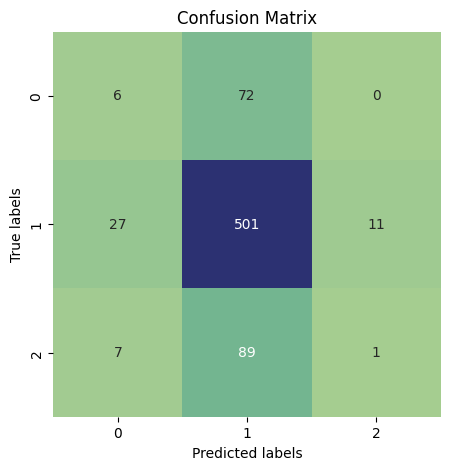

In [156]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


svm_clf = SVC(kernel='rbf', C=1, probability=True)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
dt_clf = DecisionTreeClassifier(random_state=42)
xgb_clf = xgb.XGBClassifier()


voting_clf = VotingClassifier(estimators=[('svm', svm_clf), ('rf', rf_clf), ('dt', dt_clf), ('xgb', xgb_clf)], voting='hard')


voting_clf.fit(x_train_tfidf_matrix, y_train_mapped)


y_test_pred_voting = voting_clf.predict(x_test_tfidf_matrix)


accuracy_voting = accuracy_score(y_test_mapped, y_test_pred_voting)
print(f"Voting Classifier Accuracy: {accuracy_voting:.4f}")


cm = confusion_matrix(y_test_mapped, y_test_pred_voting)
class_labels = ['0', '1', '2']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()
